

*NUETPUS = Nuclear Electricity Net Generation*

This dataset tracks the total amount of electricity generated by U.S. nuclear power plants from 1957 to present, measured in Million Kilowatthours.This measures the raw output, how many millions of kilowatthours nuclear plants actually produced in a given period.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/MER_T08_01 (1)_NUETPUS.csv')
df.head()

,MSN,YYYYMM,Value,Column_Order,Description,Unit
0,NUETPUS,195713,10,3,Nuclear Electricity Net Generation,Million Kilowatthours
1,NUETPUS,195813,165,3,Nuclear Electricity Net Generation,Million Kilowatthours
2,NUETPUS,195913,188,3,Nuclear Electricity Net Generation,Million Kilowatthours
3,NUETPUS,196013,518,3,Nuclear Electricity Net Generation,Million Kilowatthours
4,NUETPUS,196113,1692,3,Nuclear Electricity Net Generation,Million Kilowatthours


In [2]:

df.describe()

,YYYYMM,Value,Column_Order
count,705.000000,705.000000,705.0
mean,199828.838298,91058.236879,3.0
std,1599.511999,160443.173964,0.0
min,195713.000000,10.000000,3.0
25%,198505.000000,34944.000000,3.0
50%,199812.000000,59170.000000,3.0
75%,201206.000000,67226.000000,3.0
max,202513.000000,809409.000000,3.0


In [3]:

year_data = df[df["YYYYMM"] % 100 == 13].copy()
year_data["Year"] = year_data["YYYYMM"] // 100
year_data.head()

,MSN,YYYYMM,Value,Column_Order,Description,Unit,Year
0,NUETPUS,195713,10,3,Nuclear Electricity Net Generation,Million Kilowatthours,1957
1,NUETPUS,195813,165,3,Nuclear Electricity Net Generation,Million Kilowatthours,1958
2,NUETPUS,195913,188,3,Nuclear Electricity Net Generation,Million Kilowatthours,1959
3,NUETPUS,196013,518,3,Nuclear Electricity Net Generation,Million Kilowatthours,1960
4,NUETPUS,196113,1692,3,Nuclear Electricity Net Generation,Million Kilowatthours,1961


### Nuclear Electricity Net Generation Over Time (Annual)

This graph shows the total electricity produced by U.S. nuclear plants each year from 1957 to present. Output was nearly zero in the late 1950s and grew rapidly through the 1970s and 80s as new plants came online, reaching around 800,000 million kWh by the early 2000s. Since then generation has plateaued and stayed relatively flat, showing that the fleet stopped growing and has just been maintaining steady output.

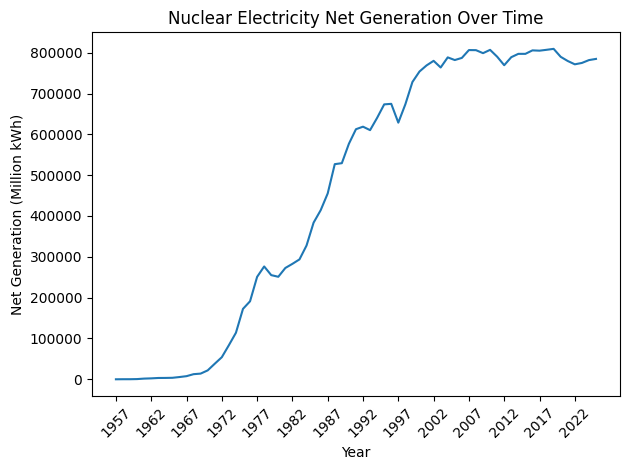

In [4]:

plt.plot(year_data["Year"], year_data["Value"])
plt.xticks(year_data["Year"][::5], rotation=45)

plt.xlabel("Year")
plt.ylabel("Net Generation (Million kWh)")
plt.title("Nuclear Electricity Net Generation Over Time")
plt.tight_layout()
plt.show()

### Nuclear Electricity Net Generation Over Time (Monthly)

This is the same data broken down by month, showing the seasonal ups and downs within each year. The recurring dips reflect planned refueling outages that happen throughout the year when plants briefly go offline for maintenance. The overall upward trend from the 1970s through the 2000s is still clearly visible before leveling off in recent years.

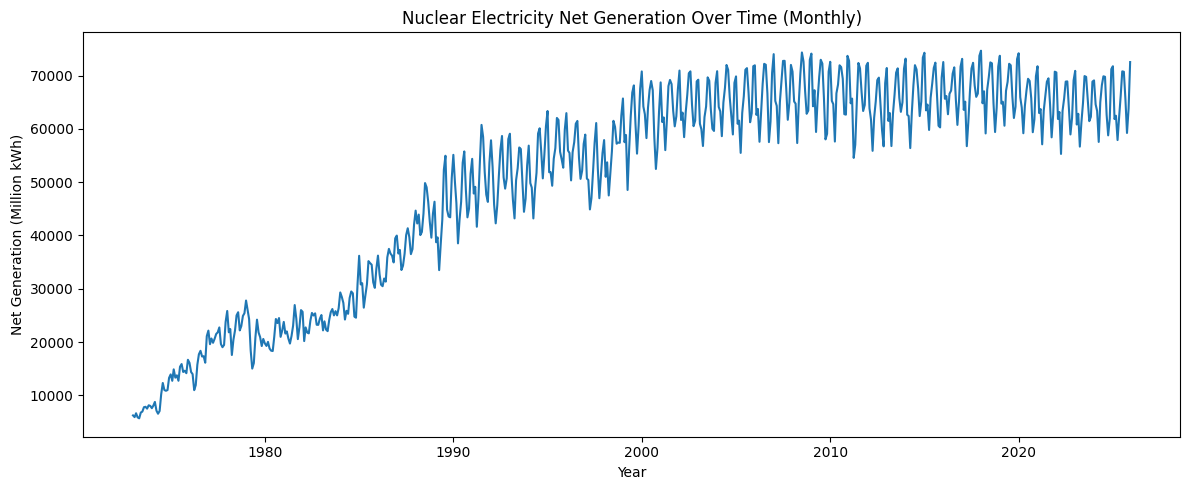

In [5]:

month_data = df[df["YYYYMM"] % 100 != 13].copy()
month_data["Date"] = pd.to_datetime(month_data["YYYYMM"].astype(str), format="%Y%m")

plt.figure(figsize=(12, 5))
plt.plot(month_data["Date"], month_data["Value"])

plt.xlabel("Year")
plt.ylabel("Net Generation (Million kWh)")
plt.title("Nuclear Electricity Net Generation Over Time (Monthly)")
plt.tight_layout()
plt.show()

### Year over Year Change in Nuclear Net Generation

This graph shows how much total output changed from one year to the next in million kWh. The biggest jumps happened in the 1970s and 80s when many new plants were coming online, with the largest single spike around 1988 at over 70,000 million kWh. The deepest drop came around 1997, and after 2000 the swings became much smaller, reflecting a mature fleet with stable but slowly declining output.

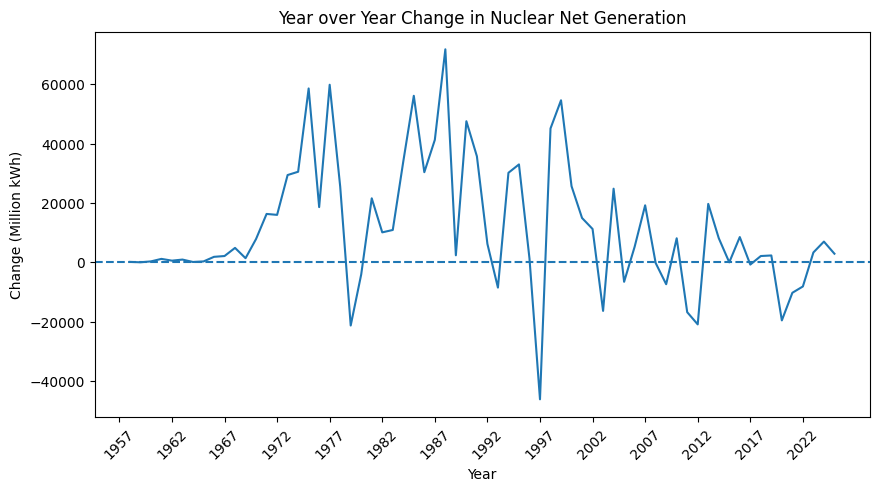

In [6]:

year_data["yoy diff"] = year_data["Value"].diff()

plt.figure(figsize=(10, 5))
plt.plot(year_data["Year"], year_data["yoy diff"])
plt.xticks(year_data["Year"][::5], rotation=45)
plt.axhline(0, linestyle='--')
plt.title("Year over Year Change in Nuclear Net Generation")
plt.xlabel("Year")
plt.ylabel("Change (Million kWh)")
plt.show()

The biggest single-year drop was in 1997 at -46,085 million kWh, which was an unusually large dip likely caused by a combination of plant outages and the beginning of early retirements as cheap natural gas started competing with nuclear. The 1979 drop of -21,248 million kWh lines up directly with the Three Mile Island accident, which triggered safety shutdowns across multiple plants. On the growth side, 1988 saw the biggest single-year jump at +71,703 million kWh, right in the middle of the construction boom era when dozens of new plants were finishing construction and coming online all at once. The mid-to-late 1970s and 1980s dominate the growth list, confirming that this was the peak expansion period for U.S. nuclear generation.

In [7]:

lowest_drops = year_data.nsmallest(10, "yoy diff")
print("Biggest Drops:")
print(lowest_drops[["Year", "yoy diff"]])

highest_spikes = year_data.nlargest(10, "yoy diff")
print("\nBiggest Growth:")
print(highest_spikes[["Year", "yoy diff"]])

Biggest Drops:
     Year  yoy diff
340  1997  -46085.0
106  1979  -21248.0
535  2012  -20873.0
639  2020  -19530.0
522  2011  -16764.0
418  2003  -16331.0
652  2021  -10234.0
288  1993   -8485.0
665  2022   -8108.0
496  2009   -7353.0

Biggest Growth:
     Year  yoy diff
223  1988   71703.0
80   1977   59779.0
54   1975   58529.0
184  1985   56057.0
366  1999   54552.0
249  1990   47507.0
353  1998   45058.0
210  1987   41232.0
262  1991   35703.0
171  1984   33957.0


In [8]:

policy_data = pd.read_csv('../data/policy.csv')

yearly_policy_data = pd.merge(year_data, policy_data, on="Year", how="left")

yearly_policy_data["Event_Name"] = yearly_policy_data["Event_Name"].fillna("None")
yearly_policy_data["Event_Type"] = yearly_policy_data["Event_Type"].fillna("None")
yearly_policy_data["Policy_Indicator"] = yearly_policy_data["Policy_Indicator"].fillna(0)
yearly_policy_data["cumulative_policy"] = yearly_policy_data["Policy_Indicator"].cumsum()

yearly_policy_data = yearly_policy_data.drop(columns=["Unit", "Column_Order", "YYYYMM", "Source", "Description_x", "Description_y"])
yearly_policy_data.head(20)

,MSN,Value,Year,yoy diff,Event_Name,Event_Type,Policy_Indicator,cumulative_policy
0,NUETPUS,10,1957,NaN,Price-Anderson Nuclear Industries Act,Pro-Nuclear Policy,1.0,1.0
1,NUETPUS,165,1958,155.0,None,None,0.0,1.0
2,NUETPUS,188,1959,23.0,None,None,0.0,1.0
3,NUETPUS,518,1960,330.0,None,None,0.0,1.0
4,NUETPUS,1692,1961,1174.0,None,None,0.0,1.0
5,NUETPUS,2270,1962,578.0,None,None,0.0,1.0
6,NUETPUS,3212,1963,942.0,None,None,0.0,1.0
7,NUETPUS,3343,1964,131.0,None,None,0.0,1.0
8,NUETPUS,3657,1965,314.0,None,None,0.0,1.0
9,NUETPUS,5520,1966,1863.0,None,None,0.0,1.0


### Nuclear Net Generation vs Policy Trends Over Time

This dual-axis chart overlays total nuclear generation (blue) with cumulative policy sentiment (red). Even as policy turned sharply negative in the late 1980s, generation kept rising because plants already under construction kept coming online. However once policy bottomed out around 1990, generation growth eventually slowed and flattened — showing that policy shapes long-term output rather than causing immediate changes.

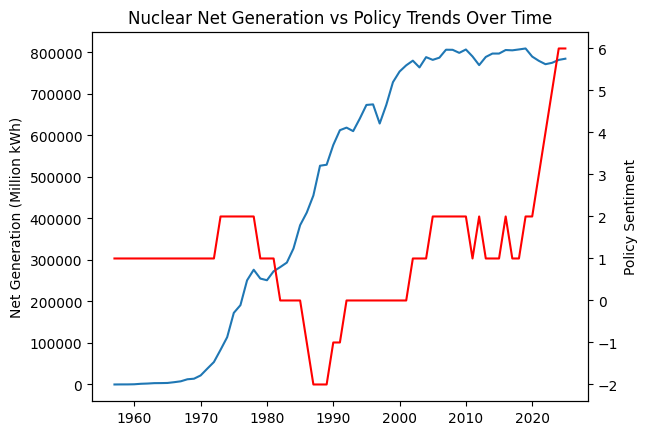

In [9]:
# Dual axis chart: net generation vs policy sentiment
fig, ax1 = plt.subplots()

ax1.plot(yearly_policy_data["Year"], yearly_policy_data["Value"])
ax1.set_ylabel("Net Generation (Million kWh)")

ax2 = ax1.twinx()
ax2.plot(yearly_policy_data["Year"], yearly_policy_data["cumulative_policy"], color="red")
ax2.set_ylabel("Policy Sentiment")

plt.title("Nuclear Net Generation vs Policy Trends Over Time")
plt.show()

### Nuclear Net Generation vs Lagged Policy (5-Year Delay)

This chart shifts the policy line 5 years forward to test whether policy decisions take time to affect actual output. The sharp policy drop around 1985-1995 lines up closely with the period when generation growth started slowing down, supporting the idea that negative policy had a delayed impact. The recovery in policy sentiment from 2000 onward also aligns with generation stabilizing at a high level rather than declining further.

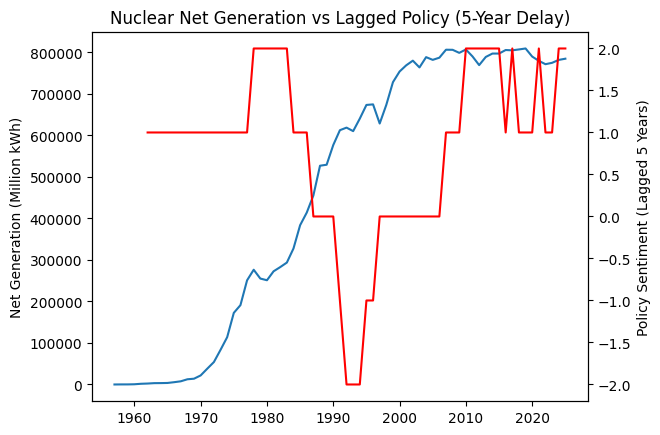

In [10]:
# Testing 5-year policy lag effect
yearly_policy_data["policy_lag_5"] = yearly_policy_data["cumulative_policy"].shift(5)

fig, ax1 = plt.subplots()

ax1.plot(yearly_policy_data["Year"], yearly_policy_data["Value"])
ax1.set_ylabel("Net Generation (Million kWh)")

ax2 = ax1.twinx()
ax2.plot(yearly_policy_data["Year"], yearly_policy_data["policy_lag_5"], color="red")
ax2.set_ylabel("Policy Sentiment (Lagged 5 Years)")

plt.title("Nuclear Net Generation vs Lagged Policy (5-Year Delay)")
plt.show()

### K-Means Clustering of Policy vs Net Generation Change

This scatter plot groups years into 3 clusters based on lagged policy sentiment and year-over-year generation change. The purple cluster shows years with the biggest growth jumps, mostly occurring when policy sentiment was around 0, meaning plants were expanding regardless of mixed policy. The teal and yellow clusters represent more recent years where changes were smaller and more spread out, reflecting a mature fleet that is less affected by individual policy shifts.

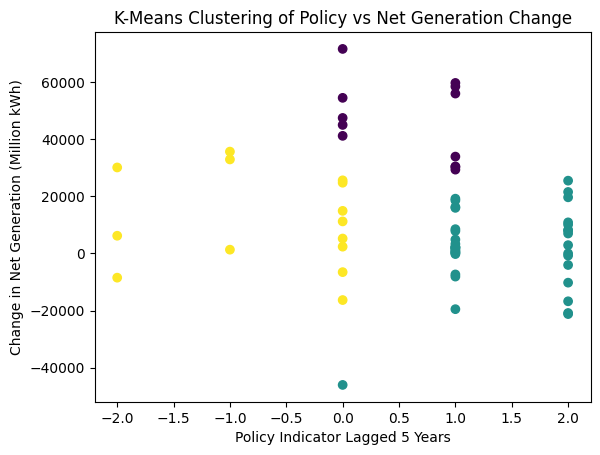

In [11]:
# K-Means clustering of policy vs generation change
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

kmeans_df = yearly_policy_data[["policy_lag_5", "yoy diff"]].dropna()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(kmeans_df)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_df["cluster"] = kmeans.fit_predict(scaled_data)

plt.scatter(
    kmeans_df["policy_lag_5"],
    kmeans_df["yoy diff"],
    c=kmeans_df["cluster"]
)

plt.xlabel("Policy Indicator Lagged 5 Years")
plt.ylabel("Change in Net Generation (Million kWh)")
plt.title("K-Means Clustering of Policy vs Net Generation Change")
plt.show()